In [29]:
%load_ext autoreload
%autoreload 2
from torchmetrics.image import PeakSignalNoiseRatio as PSNR
from torchmetrics.image import StructuralSimilarityIndexMeasure as SSIM
from torchmetrics.image.fid import FrechetInceptionDistance as FID
from torchmetrics.image.lpip import LearnedPerceptualImagePatchSimilarity as LPIPS
import os
os.chdir('/mnt/c/Users/ankit/Desktop/Msc AIML/msc-project/GAP/gap')
from utils import preprocess, resize, stats
import torch
import numpy as np
import matplotlib.pyplot as plt
if not torch.cuda.is_available():
    raise ValueError("GPU not found, code will run on CPU and can be extremely slow!")
else:
    device = torch.device("cuda:0")
from skimage.io import imsave
import time

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


ValueError: GPU not found, code will run on CPU and can be extremely slow!

# Colorization

### Full Generative

In [26]:
preds_output_path = '/mnt/c/Users/ankit/Desktop/Msc AIML/Data/results/kaggle/colorization/m40tom10 real/m40tom10/1e-1/preds/'
gt_output_path = '/mnt/c/Users/ankit/Desktop/Msc AIML/Data/results/kaggle/colorization/m40tom10 real/m40tom10/1e-1/gt/'
from BinomDataset_ffhq_color_noaug import BinomDataset

from PIL import Image
from torchvision import transforms
transform = transforms.Compose([
    transforms.ToTensor()
])
img = Image.open(gt_output_path + 'out147.png')
preds = Image.open(preds_output_path + 'out147.png')

In [29]:
np.array(img)

(256, 256, 3)

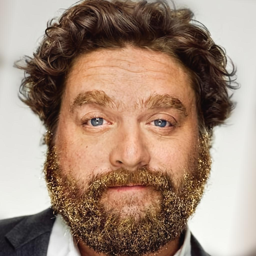

In [36]:
img

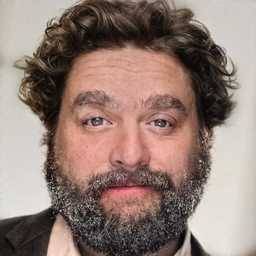

In [37]:
preds

In [38]:
psnr = PSNR()
psnr(transform(preds), transform(img))

tensor(24.4986)

In [43]:
ssim = SSIM()
ssim(transform(img)[None], transform(preds)[None])

tensor(0.9660)

In [1]:
import pandas as pd

In [2]:
main = pd.DataFrame(columns= ['Beta', 'PSNR', 'SSIM', 'LPIPS', 'FID'])

In [10]:
import os
import torch
import torchvision.transforms as transforms
from PIL import Image
import pandas as pd
from torchmetrics.image import PeakSignalNoiseRatio, StructuralSimilarityIndexMeasure
from torchmetrics.image.lpip import LearnedPerceptualImagePatchSimilarity
from torchmetrics.image.fid import FrechetInceptionDistance

# Paths to folders
ground_truth_folder = "/mnt/c/Users/ankit/Desktop/Msc AIML/Data/results/kaggle/colorization/m40tom10 real/silly/gt/"
predictions_folder = "/mnt/c/Users/ankit/Desktop/Msc AIML/Data/results/kaggle/colorization/m40tom10 real/silly/preds/"

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize the metrics and move them to the appropriate device
psnr = PeakSignalNoiseRatio().to(device)
ssim = StructuralSimilarityIndexMeasure().to(device)
lpips = LearnedPerceptualImagePatchSimilarity(net_type='alex', normalize= True).to(device)
fid = FrechetInceptionDistance(normalize= False).to(device)

# Transformation to convert images to tensors
transform = transforms.ToTensor()

# Variables to accumulate the metrics
psnr_sum = 0.0
ssim_sum = 0.0
lpips_sum = 0.0
psnr_sq_sum = 0.0
ssim_sq_sum = 0.0
lpips_sq_sum = 0.0
count = 0

# List of image files
ground_truth_files = sorted(os.listdir(ground_truth_folder))
predictions_files = sorted(os.listdir(predictions_folder))

# Iterate over the images
for gt_file, pred_file in zip(ground_truth_files, predictions_files):
    # Load the ground truth and prediction images
    gt_image = Image.open(os.path.join(ground_truth_folder, gt_file))
    pred_image = Image.open(os.path.join(predictions_folder, pred_file))

    # Convert images to tensors and move them to the appropriate device
    gt_tensor = transform(gt_image).unsqueeze(0).to(device)  # add batch dimension
    pred_tensor = transform(pred_image).unsqueeze(0).to(device)

    # Compute metrics for each image
    psnr_value = psnr(pred_tensor, gt_tensor).item()
    ssim_value = ssim(pred_tensor, gt_tensor).item()
    lpips_value = lpips(pred_tensor, gt_tensor).item()

    # Accumulate sums and squared sums
    psnr_sum += psnr_value
    ssim_sum += ssim_value
    lpips_sum += lpips_value
    psnr_sq_sum += psnr_value ** 2
    ssim_sq_sum += ssim_value ** 2
    lpips_sq_sum += lpips_value ** 2
    
    # Update FID with both real and fake images
    gt_uint8 = (gt_tensor * 255).byte()
    pred_uint8 = (pred_tensor * 255).byte()
    
    # Update FID with both real and fake images
    fid.update(pred_uint8, real=False)
    fid.update(gt_uint8, real=True)

    count += 1

# Final FID computation after all updates
fid_value = fid.compute().item()

# Compute average metrics
psnr_avg = psnr_sum / count
ssim_avg = ssim_sum / count
lpips_avg = lpips_sum / count

# Compute standard deviation metrics
psnr_std = (psnr_sq_sum / count - psnr_avg ** 2) ** 0.5
ssim_std = (ssim_sq_sum / count - ssim_avg ** 2) ** 0.5
lpips_std = (lpips_sq_sum / count - lpips_avg ** 2) ** 0.5

# Print the results
print(f'Average PSNR: {psnr_avg}, PSNR StdDev: {psnr_std}')
print(f'Average SSIM: {ssim_avg}, SSIM StdDev: {ssim_std}')
print(f'Average LPIPS: {lpips_avg}, LPIPS StdDev: {lpips_std}')
print(f'FID: {fid_value}')


df =  pd.DataFrame({'Beta': ['prettyfull'] ,'PSNR': [f'{psnr_avg:.5f}± {psnr_std:.5f}'], 'SSIM': [f'{ssim_avg:.5f}± {ssim_std:.5f}'], 'LPIPS':[ f'{lpips_avg:.5f}± {lpips_std:.5f}'], 'FID': [fid_value]})
main = pd.concat([main, df])
main

Average PSNR: 21.10601980035955, PSNR StdDev: 3.5622139051939086
Average SSIM: 0.9163204539905895, SSIM StdDev: 0.027501769751025338
Average LPIPS: 0.1321306320076639, LPIPS StdDev: 0.03425127418726317
FID: 71.67338562011719


,Beta,PSNR,SSIM,LPIPS,FID
0,full,21.10601980035955± 3.5622139051939086,0.9163204539905895± 0.027501769751025338,0.1321306320076639± 0.03425127418726317,71.673386
0,full,21.10601980035955± 3.5622139051939086,0.9163204539905895± 0.027501769751025338,0.1321306320076639± 0.03425127418726317,71.673386
0,full,21.10602± 3.56221,0.91632± 0.02750,0.13213± 0.03425,71.673386
0,full,21.10602± 3.56221,0.91632± 0.02750,0.13213± 0.03425,71.673386
0,prettyfull,21.10602± 3.56221,0.91632± 0.02750,0.13213± 0.03425,71.673386


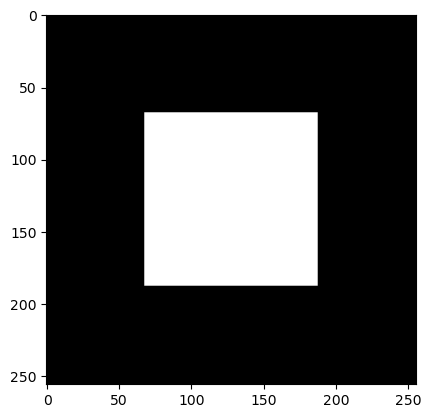

In [63]:
import numpy as np
import matplotlib.pyplot as plt
mask = np.zeros((256, 256))
start = int(256/2) - 60
end = int(256/2) + 60
mask[start:end, start:end] = 1
plt.imshow(mask, 'gray')

In [22]:
path = '/mnt/c/Users/ankit/Desktop/Msc AIML/Data/results/kaggle/colorization/m40tom10 real/m40tom10/1e-1/gt/'
file0 = 'out240.png'
file1 = 'out320.png'
file2 = 'out321.png'
img = Image.open(os.path.join(path, file0))
noise1 = Image.open(os.path.join(path, file1))
noise2 = Image.open(os.path.join(path, file2))

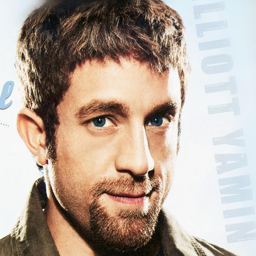

In [24]:
img

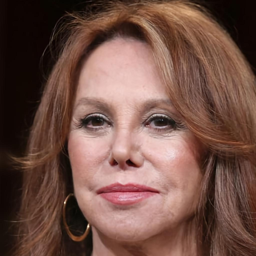

In [25]:
noise1

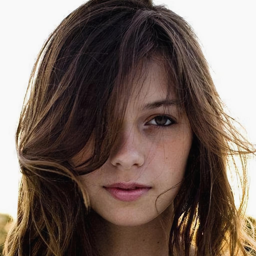

In [26]:
noise2

In [34]:
stats(np.array(img)/np.array(img).mean(), np.array(noise1)/np.array(noise1).mean(), np.array(noise2)/np.array(noise2).mean())


Shape : (256, 256, 3)

Min : 0.0

Max : 1.521396689296571

Sum : 196607.99999999997

Mean : 0.9999999999999999


Shape : (256, 256, 3)

Min : 0.0

Max : 2.9026307824168627

Sum : 196608.0

Mean : 1.0


Shape : (256, 256, 3)

Min : 0.0

Max : 2.391367216549517

Sum : 196608.00000000003

Mean : 1.0000000000000002



In [27]:
import torchvision
from torchvision.transforms.functional import pil_to_tensor

In [29]:
transform(pred_image)

tensor([[[0.6667, 0.7020, 0.7176,  ..., 0.4824, 0.5373, 0.4824],
         [0.6706, 0.6549, 0.6745,  ..., 0.4627, 0.4980, 0.4745],
         [0.6824, 0.6471, 0.6549,  ..., 0.4980, 0.5294, 0.4941],
         ...,
         [0.7137, 0.7255, 0.7255,  ..., 0.1804, 0.1843, 0.1843],
         [0.6549, 0.7059, 0.6980,  ..., 0.1843, 0.2078, 0.1725],
         [0.6627, 0.7373, 0.6902,  ..., 0.1961, 0.2157, 0.2314]],

        [[0.4824, 0.4941, 0.4745,  ..., 0.4863, 0.4471, 0.3843],
         [0.4980, 0.4471, 0.4627,  ..., 0.4510, 0.4588, 0.4353],
         [0.4863, 0.4627, 0.4667,  ..., 0.4627, 0.4824, 0.4549],
         ...,
         [0.7647, 0.7765, 0.7686,  ..., 0.4157, 0.4196, 0.3765],
         [0.8118, 0.7922, 0.7882,  ..., 0.3922, 0.4078, 0.3412],
         [0.6902, 0.7804, 0.7725,  ..., 0.3529, 0.4235, 0.3804]],

        [[0.3647, 0.3137, 0.3490,  ..., 0.4078, 0.4118, 0.3922],
         [0.3255, 0.2824, 0.3176,  ..., 0.4235, 0.4235, 0.4078],
         [0.3373, 0.3176, 0.3176,  ..., 0.4196, 0.4471, 0.

### Diversity Denoising